# v2 Fantasy Football Draft Projection Model — Deliverable

Per PRD #11: 2026 projections for all four positions, trained through the completed 2025 season,
led by the corrected v2 scoreboards. Per ADR-0014/issue #19, **Disagreement Edge** is the headline
win-condition metric — not whether the model agrees with ADP overall, but whether the model's
*disagreements* with ADP are trustworthy. Matched-population Spearman and tier accuracy (ADR-0010/
ADR-0011) remain as supporting signals only. The pooled VOR cross-position scoreboard (ADR-0012) was
dropped entirely per issue #15 — only the four per-position scoreboards below.

Rookies are excluded per ADR-0006: every row here is a Veteran (at least one prior season and
>=16 career games before the target season).

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
projections = pd.read_csv("../output/v2_projections.csv", comment="#")
with open("../output/backtest_report_v2.json") as f:
    backtest_report = json.load(f)

projections.shape

(379, 53)

## Final Projections

All four positions' full Projections for **2026** (trained through the completed 2025 season),
combined into one dataframe — the CSV deliverable itself. Every position now runs the simplest
version of each feature family (no multi-season memory window, no age/experience or
Strength-of-Schedule encoding, no Depth-Chart Competition feature) per issue #16's Disagreement Edge
re-sweep, which found none of the previously-adopted variants distinguishable from noise.
`full_projection_p50` is the season-total point estimate (`fantasy_points_p50 *
games_played_estimate`); `full_projection_p10`/`full_projection_p90` are its boom/bust range.

In [2]:
projections.groupby("position").size().rename("players_projected")

position
QB     50
RB     96
TE     85
WR    148
Name: players_projected, dtype: int64

In [3]:
key_columns = [
    "position", "player_name", "target_season", "games_played_estimate",
    "fantasy_points_p10", "fantasy_points_p50", "fantasy_points_p90",
    "full_projection_p10", "full_projection_p50", "full_projection_p90",
]
projections[key_columns].sort_values(
    ["position", "full_projection_p50"], ascending=[True, False]
).groupby("position").head(5)

,position,player_name,target_season,games_played_estimate,fantasy_points_p10,fantasy_points_p50,fantasy_points_p90,full_projection_p10,full_projection_p50,full_projection_p90
114,QB,Justin Fields,2026,6.000000,3.644554,21.855259,26.521519,21.867324,131.131554,159.129112
100,QB,Dak Prescott,2026,6.895189,6.671991,17.236533,30.227613,46.004641,118.849152,208.425104
98,QB,Matthew Stafford,2026,6.895189,7.420791,17.109017,23.897139,51.167756,117.969909,164.775292
101,QB,Jared Goff,2026,6.895189,6.275279,16.404085,24.113860,43.269232,113.109264,166.269622
105,QB,Josh Allen,2026,6.895189,6.134750,16.198876,33.206718,42.300260,111.694315,228.966597
1,RB,Christian McCaffrey,2026,8.346008,3.989210,21.882592,42.705491,33.293973,182.632281,356.420350
16,RB,Jonathan Taylor,2026,8.765988,2.605058,17.559789,34.448772,22.835909,153.928903,301.977537
29,RB,James Cook,2026,7.344712,2.491384,16.896266,32.092541,18.298497,124.098214,235.710477
42,RB,Bijan Robinson,2026,7.344712,3.910088,14.653932,45.419708,28.718469,107.628909,333.594683
50,RB,De'Von Achane,2026,7.344712,3.781404,11.874874,31.024562,27.773325,87.217528,227.866481


## Boom/Bust Ranges (P10/P50/P90)

Top 12 players per position by `full_projection_p50`, with the P10-P90 range as an error bar.

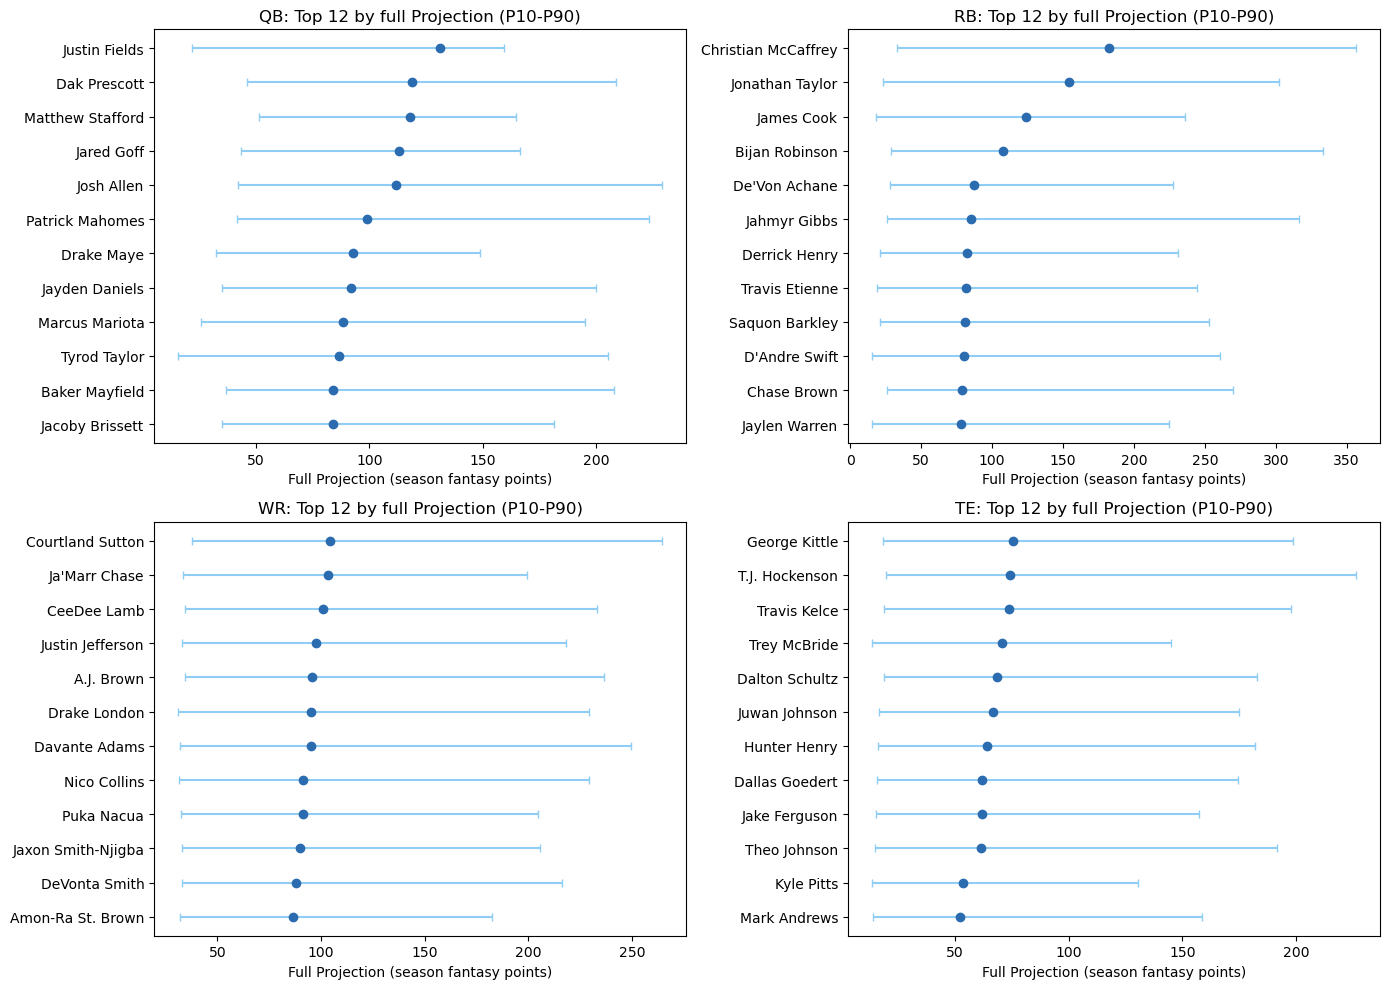

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
positions = ["QB", "RB", "WR", "TE"]

for ax, position in zip(axes.flat, positions):
    top = (
        projections.loc[projections["position"] == position]
        .nlargest(12, "full_projection_p50")
        .sort_values("full_projection_p50")
    )
    y = range(len(top))
    lower_err = top["full_projection_p50"] - top["full_projection_p10"]
    upper_err = top["full_projection_p90"] - top["full_projection_p50"]
    ax.errorbar(
        top["full_projection_p50"], y,
        xerr=[lower_err, upper_err],
        fmt="o", capsize=3, color="#2b6cb0", ecolor="#90cdf4",
    )
    ax.set_yticks(list(y))
    ax.set_yticklabels(top["player_name"])
    ax.set_title(f"{position}: Top 12 by full Projection (P10-P90)")
    ax.set_xlabel("Full Projection (season fantasy points)")

fig.tight_layout()
fig.savefig("../output/v2_boom_bust_ranges.png", dpi=110)
plt.show()

## Model vs. live 2026 FFC ADP

Live Fantasy Football Calculator ADP for the 2026 draft class, joined onto the projections by
crosswalked `player_id`. `model_rank`/`adp_rank` are computed per position, over the players FFC's
market has actually drafted (non-null `adp`); `rank_diff` is `model_rank - adp_rank` (negative means
the model likes the player more than the market does). `large_disagreement` flags `|rank_diff| > 12`
— one draft round, the same `LARGE_DISAGREEMENT_THRESHOLD` the Disagreement Edge win-rate below is
scored on (per ADR-0014's note that issue #17's flagged cases and the scored cases should be the
same thing, not two separate ad hoc definitions of "biggest disagreement").

In [5]:
matched = projections.dropna(subset=["adp"])
adp_columns = [
    "position", "player_name", "full_projection_p50", "adp", "model_rank", "adp_rank", "rank_diff",
]
matched[adp_columns].sort_values(["position", "adp_rank"]).groupby("position").head(10)

,position,player_name,full_projection_p50,adp,model_rank,adp_rank,rank_diff
105,QB,Josh Allen,111.694315,27.9,4.0,1.0,3.0
113,QB,Joe Burrow,68.807791,47.6,16.0,2.0,14.0
103,QB,Lamar Jackson,71.210633,52.9,13.0,3.0,10.0
100,QB,Dak Prescott,118.849152,59.2,1.0,4.0,-3.0
121,QB,Drake Maye,92.972140,64.9,6.0,5.0,1.0
102,QB,Patrick Mahomes,99.016212,76.1,5.0,6.0,-1.0
111,QB,Justin Herbert,78.447267,78.0,12.0,7.0,5.0
115,QB,Trevor Lawrence,61.453188,79.8,19.0,8.0,11.0
122,QB,Jayden Daniels,92.042361,85.3,7.0,9.0,-2.0
112,QB,Jalen Hurts,82.560707,93.5,10.0,10.0,0.0


### Largest disagreements per position

Where the model and the 2026 market disagree by more than one draft round — the players this model
is actually taking a position on, not just re-stating the crowd's board.

In [6]:
disagreements = matched.loc[matched["large_disagreement"]]
disagreements[adp_columns].reindex(
    disagreements["rank_diff"].abs().sort_values(ascending=False).index
).groupby("position").head(5)

,position,player_name,full_projection_p50,adp,model_rank,adp_rank,rank_diff
154,WR,Courtland Sutton,104.391931,69.9,1.0,32.0,-31.0
153,WR,Cooper Kupp,62.348143,164.8,32.0,58.0,-26.0
159,WR,Jakobi Meyers,84.869704,98.3,16.0,42.0,-26.0
172,WR,Jauan Jennings,66.922123,129.5,28.0,50.0,-22.0
245,WR,Ladd McConkey,58.240321,37.1,40.0,19.0,21.0
309,TE,T.J. Hockenson,74.231483,156.6,2.0,17.0,-15.0
113,QB,Joe Burrow,68.807791,47.6,16.0,2.0,14.0
41,RB,Kenneth Walker,58.234950,22.8,24.0,11.0,13.0


## Walk-Forward Backtest Report (2012-2025)

Per position, computed on the Matched Population (ADR-0010: only players FFC's market actually
drafted that season). **Disagreement Edge (ADR-0014) is the headline win condition**: the model's
*disagreements* with ADP are trustworthy when the win-rate on large disagreements (>12 ranks) is
significantly different from the 50% noise null, per the season-block bootstrap CI. Matched-population
Spearman ρ and tier accuracy vs. ADP are reported alongside as supporting signals only — they measure
overall rank agreement, which ADR-0014 explicitly demoted from decision metric because a feature (or a
whole model) can look good on those by hugging ADP's own ranking, without adding any real disagreement
signal.

In [7]:
def disagreement_verdict(edge: dict) -> str:
    lo, hi = edge["win_rate_ci"]
    if lo > 0.5:
        return "beats noise"
    if hi < 0.5:
        return "loses to noise"
    return "indistinguishable from noise"


rows = []
for position, report in backtest_report.items():
    edge = report["disagreement_edge"]
    rows.append(
        {
            "position": position,
            "n_matched": report["n_matched"],
            "correlation": edge["correlation"],
            "correlation_ci": edge["correlation_ci"],
            "win_rate": edge["win_rate"],
            "win_rate_ci": edge["win_rate_ci"],
            "n_large_disagreements": edge["n_large_disagreements"],
            "verdict": disagreement_verdict(edge),
        }
    )

disagreement_df = pd.DataFrame(rows).set_index("position")
disagreement_df

,n_matched,correlation,correlation_ci,win_rate,win_rate_ci,n_large_disagreements,verdict
position,,,,,,,
RB,414,0.224332,"[0.07301204266177141, 0.4107484357327233]",0.377551,"[0.2716028942850135, 0.4610938693659281]",98,loses to noise
QB,198,0.334156,"[0.2083706442715088, 0.5710770580437754]",0.272727,"[0.1960151802656547, 0.5714285714285714]",11,indistinguishable from noise
WR,502,0.232320,"[0.1365322985459349, 0.3147702892412253]",0.324468,"[0.3050847457627119, 0.4684886003321757]",188,loses to noise
TE,160,0.364629,"[0.0631048363943198, 0.5363167839306984]",0.000000,"[0.0, 0.75]",1,indistinguishable from noise


### Supporting metrics: matched-population Spearman and tier accuracy vs. ADP

Not the win condition (see above) — tracked here for overall model-quality context only.

In [8]:
supporting_rows = []
for position, report in backtest_report.items():
    tiers = report["tier_accuracy"]
    supporting_rows.append(
        {
            "position": position,
            "model_spearman": report["matched_population"]["model"],
            "adp_spearman": report["matched_population"]["adp"],
            "model_tier_accuracy": tiers["model"]["accuracy"],
            "adp_tier_accuracy": tiers["adp"]["accuracy"],
            "tier_verdict": tiers["verdict"],
        }
    )

pd.DataFrame(supporting_rows).set_index("position")

,model_spearman,adp_spearman,model_tier_accuracy,adp_tier_accuracy,tier_verdict
position,,,,,
RB,0.306930,0.498968,0.386473,0.471014,lost
QB,0.161965,0.397768,0.323232,0.383838,lost
WR,0.271939,0.520045,0.444223,0.541833,lost
TE,0.307482,0.362735,0.312500,0.350000,lost


### Reading the Disagreement Edge verdict

QB and TE remain underpowered for this exercise — `n_large_disagreements` is small enough (see
`docs/research/feature-family-re-sweep-2026-07.md`'s Caveats) that a wide win-rate CI is expected,
not a sign the metric is broken. Where the CI excludes 50%, that's the model's disagreements with ADP
carrying real, not noise, information. Where it doesn't, that position's model isn't yet earning its
disagreements with the market — a candidate for v2.1 feature work, not a reason to withhold that
position's projections (v1's precedent: useful, credible per-position signal, not a finished
product).